<a href="https://colab.research.google.com/github/mushrifahamed/DL-Assignment1/blob/model_vgg16/02_vgg16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Download Dataset

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

print("Path to dataset files:", path)

100%|██████████| 149M/149M [00:00<00:00, 186MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/masoudnickparvar/brain-tumor-mri-dataset/versions/1


In [ ]:
!nvidia-smi
!python --version

# Optional: reproducibility
import os, random, numpy as np, tensorflow as tf
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

# If your dataset is in Drive:
from google.colab import drive
drive.mount('/content/drive')
DATA_ROOT = "/content/drive/MyDrive/DL-Assignment/brain_tumor_dataset"


Sat Oct 11 16:28:56 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

Dataset Loder

In [ ]:
import os, tensorflow as tf
if os.path.exists("vgg16_phase1.keras"):
    model = tf.keras.models.load_model("vgg16_phase1.keras")
from tensorflow.keras import layers
from tensorflow.keras.applications.vgg16 import preprocess_input

# ===== paths =====
DATA_ROOT = "/content/drive/MyDrive/DL-Assignment/brain_tumor_dataset"   # <-- change to your folder path
TRAIN_DIR = os.path.join(DATA_ROOT, "Training")
TEST_DIR  = os.path.join(DATA_ROOT, "Testing")

# ===== settings (keep same across all 4 models) =====
IMG_SIZE  = 224          # VGG16 input size
BATCH     = 32
SEED      = 42
AUTOTUNE  = tf.data.AUTOTUNE
VAL_SPLIT = 0.15         # 15% of Training used as validation

# ===== create train/val directly from Training/ (stratified per class) =====
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="categorical",         # one-hot for 4 classes
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH,
    shuffle=True,
    seed=SEED,
    validation_split=VAL_SPLIT,
    subset="training",
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="categorical",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH,
    shuffle=False,
    validation_split=VAL_SPLIT,
    subset="validation",
    seed=SEED,
)

# ===== test from Testing/ (no split, no shuffle) =====
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="categorical",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH,
    shuffle=False,
)

class_names = train_ds.class_names
print("Class order:", class_names)    # e.g. ['glioma','meningioma','notumor','pituitary']

# ===== data augmentation (train only) =====
augment = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name="augment")

def vgg_preprocess(x, y):
    return preprocess_input(x), y     # required for VGG16 weights

# ===== final pipelines (fast) =====
def prep_train(ds):
    return (ds
            .map(lambda x,y: (augment(x, training=True), y), num_parallel_calls=AUTOTUNE)
            .map(vgg_preprocess, num_parallel_calls=AUTOTUNE)
            .cache().prefetch(AUTOTUNE))

def prep_eval(ds):
    return (ds
            .map(vgg_preprocess, num_parallel_calls=AUTOTUNE)
            .cache().prefetch(AUTOTUNE))

train_pp = prep_train(train_ds)
val_pp   = prep_eval(val_ds)
test_pp  = prep_eval(test_ds)


Found 5721 files belonging to 4 classes.
Using 4863 files for training.
Found 5721 files belonging to 4 classes.
Using 858 files for validation.
Found 1312 files belonging to 4 classes.
Class order: ['glioma', 'meningioma', 'notumor', 'pituitary']


Pipelines (augmentation + VGG16 preprocess)

In [ ]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))
from tensorflow.keras import layers
from tensorflow.keras.applications.vgg16 import preprocess_input

IMG_SIZE = 224
BATCH = 32
AUTOTUNE = tf.data.AUTOTUNE

# If you already created train_ds/val_ds/test_ds, reuse them; otherwise run the creation cell again.
augment = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name="augment")

def vgg_preprocess(x, y):
    return preprocess_input(x), y

def prep_train(ds):
    return (ds
            .map(lambda x,y: (augment(x, training=True), y), num_parallel_calls=AUTOTUNE)
            .map(vgg_preprocess, num_parallel_calls=AUTOTUNE)
            .cache().prefetch(AUTOTUNE))

def prep_eval(ds):
    return (ds
            .map(vgg_preprocess, num_parallel_calls=AUTOTUNE)
            .cache().prefetch(AUTOTUNE))

train_pp = prep_train(train_ds)
val_pp   = prep_eval(val_ds)
test_pp  = prep_eval(test_ds)


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Class distribution & class weights (helps with imbalance)

In [ ]:
import numpy as np, collections

# Count per-class from the TRAIN split
ys = np.concatenate([y.numpy() for _, y in train_ds.unbatch().batch(10000)])
counts = ys.sum(axis=0)
total = counts.sum()
class_weights = {i: float(total/(len(counts)*counts[i])) for i in range(len(counts))}

print("Class names:", class_names)
print("Train counts:", dict(zip(class_names, counts.astype(int))))
print("Class weights:", class_weights)


Class names: ['glioma', 'meningioma', 'notumor', 'pituitary']
Train counts: {'glioma': np.int64(1149), 'meningioma': np.int64(1155), 'notumor': np.int64(1335), 'pituitary': np.int64(1224)}
Class weights: {0: 1.0580940246582031, 1: 1.0525974035263062, 2: 0.9106741547584534, 3: 0.9932597875595093}


Build VGG16 transfer model

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')
from tensorflow.keras import layers, models, optimizers, callbacks

base = VGG16(include_top=False, weights="imagenet", input_shape=(IMG_SIZE, IMG_SIZE, 3))
base.trainable = False  # Phase 1: freeze

inputs = layers.Input((IMG_SIZE, IMG_SIZE, 3))
# (We already augment & preprocess in the pipeline)
x = base(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(len(class_names), activation="softmax", dtype="float32")(x)
model = models.Model(inputs, outputs)

model.compile(
    optimizer=optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy", tf.keras.metrics.Precision(name="precision"), tf.keras.metrics.Recall(name="recall")]
)
model.summary()


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,044 (56.64 MB)

 Trainable params: 132,356 (517.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Callbacks

In [ ]:
cbs = [
  callbacks.ModelCheckpoint("vgg16_best.h5", monitor="val_accuracy", save_best_only=True),
  callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6),
  callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
]


Train — Phase 1 (frozen base)

In [ ]:
hist1 = model.fit(
    train_pp,
    epochs=15,
    validation_data=val_pp,
    class_weight=class_weights,   # optional but recommended if counts are imbalanced
    callbacks=cbs
)

model.save("vgg16_phase1.keras")

Epoch 1/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 511ms/step - accuracy: 0.5651 - loss: 1.9872 - precision: 0.5740 - recall: 0.5458

152/152 ━━━━━━━━━━━━━━━━━━━━ 156s 898ms/step - accuracy: 0.5658 - loss: 1.9821 - precision: 0.5747 - recall: 0.5464 - val_accuracy: 0.9744 - val_loss: 0.1495 - val_precision: 0.9775 - val_recall: 0.9615 - learning_rate: 0.0010
Epoch 2/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 9s 59ms/step - accuracy: 0.7667 - loss: 0.5956 - precision: 0.7976 - recall: 0.7381 - val_accuracy: 0.9406 - val_loss: 0.2230 - val_precision: 0.9527 - val_recall: 0.9149 - learning_rate: 0.0010
Epoch 3/15
151/152 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.8045 - loss: 0.5143 - precision: 0.8296 - recall: 0.7757

152/152 ━━━━━━━━━━━━━━━━━━━━ 9s 61ms/step - accuracy: 0.8045 - loss: 0.5141 - precision: 0.8297 - recall: 0.7758 - val_accuracy: 0.9767 - val_loss: 0.1104 - val_precision: 0.9800 - val_recall: 0.9732 - learning_rate: 0.0010
Epoch 4/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.8208 - loss: 0.4865 - precision: 0.8381 - recall: 0.7908

152/152 ━━━━━━━━━━━━━━━━━━━━ 9s 62ms/step - accuracy: 0.8208 - loss: 0.4864 - precision: 0.8382 - recall: 0.7908 - val_accuracy: 0.9837 - val_loss: 0.1179 - val_precision: 0.9847 - val_recall: 0.9767 - learning_rate: 0.0010
Epoch 5/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 9s 60ms/step - accuracy: 0.8333 - loss: 0.4338 - precision: 0.8533 - recall: 0.8185 - val_accuracy: 0.9767 - val_loss: 0.1140 - val_precision: 0.9835 - val_recall: 0.9709 - learning_rate: 0.0010
Epoch 6/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.8465 - loss: 0.3996 - precision: 0.8654 - recall: 0.8293

152/152 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - accuracy: 0.8466 - loss: 0.3996 - precision: 0.8655 - recall: 0.8294 - val_accuracy: 0.9895 - val_loss: 0.0827 - val_precision: 0.9906 - val_recall: 0.9848 - learning_rate: 0.0010
Epoch 7/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - accuracy: 0.8697 - loss: 0.3677 - precision: 0.8879 - recall: 0.8501 - val_accuracy: 0.9825 - val_loss: 0.0908 - val_precision: 0.9894 - val_recall: 0.9802 - learning_rate: 0.0010
Epoch 8/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.8665 - loss: 0.3487 - precision: 0.8863 - recall: 0.8502

152/152 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - accuracy: 0.8665 - loss: 0.3488 - precision: 0.8863 - recall: 0.8503 - val_accuracy: 0.9930 - val_loss: 0.0554 - val_precision: 0.9930 - val_recall: 0.9918 - learning_rate: 0.0010
Epoch 9/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - accuracy: 0.8642 - loss: 0.3628 - precision: 0.8811 - recall: 0.8491 - val_accuracy: 0.9779 - val_loss: 0.1053 - val_precision: 0.9823 - val_recall: 0.9709 - learning_rate: 0.0010
Epoch 10/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.8685 - loss: 0.3511 - precision: 0.8848 - recall: 0.8553

152/152 ━━━━━━━━━━━━━━━━━━━━ 10s 66ms/step - accuracy: 0.8686 - loss: 0.3510 - precision: 0.8848 - recall: 0.8554 - val_accuracy: 0.9953 - val_loss: 0.0458 - val_precision: 0.9953 - val_recall: 0.9953 - learning_rate: 0.0010
Epoch 11/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - accuracy: 0.8874 - loss: 0.3080 - precision: 0.9013 - recall: 0.8735 - val_accuracy: 0.9767 - val_loss: 0.0893 - val_precision: 0.9812 - val_recall: 0.9755 - learning_rate: 0.0010
Epoch 12/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - accuracy: 0.8809 - loss: 0.3199 - precision: 0.8948 - recall: 0.8687 - val_accuracy: 0.9779 - val_loss: 0.1039 - val_precision: 0.9801 - val_recall: 0.9755 - learning_rate: 0.0010
Epoch 13/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - accuracy: 0.8865 - loss: 0.3025 - precision: 0.8962 - recall: 0.8742 - val_accuracy: 0.9895 - val_loss: 0.0628 - val_precision: 0.9895 - val_recall: 0.9860 - learning_rate: 0.0010
Epoch 14/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - accurac

Fine-tune — Phase 2 (unfreeze last VGG blocks, small LR)

In [ ]:
# Unfreeze top ~2 blocks (~24 conv layers) — adjust if you see overfitting
for layer in base.layers:
    layer.trainable = False
for layer in base.layers[-24:]:
    layer.trainable = True

model.compile(
    optimizer=optimizers.Adam(5e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy", tf.keras.metrics.Precision(name="precision"), tf.keras.metrics.Recall(name="recall")]
)

hist2 = model.fit(
    train_pp,
    epochs=10,
    validation_data=val_pp,
    class_weight=class_weights,
    callbacks=cbs
)


Epoch 1/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 264s 903ms/step - accuracy: 0.7838 - loss: 0.6862 - precision: 0.8130 - recall: 0.7411 - val_accuracy: 0.9732 - val_loss: 0.1670 - val_precision: 0.9821 - val_recall: 0.9615 - learning_rate: 5.0000e-05
Epoch 2/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 28s 187ms/step - accuracy: 0.9276 - loss: 0.2163 - precision: 0.9343 - recall: 0.9160 - val_accuracy: 0.9837 - val_loss: 0.0789 - val_precision: 0.9882 - val_recall: 0.9779 - learning_rate: 5.0000e-05
Epoch 3/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 28s 183ms/step - accuracy: 0.9422 - loss: 0.1510 - precision: 0.9474 - recall: 0.9375 - val_accuracy: 0.9662 - val_loss: 0.0977 - val_precision: 0.9662 - val_recall: 0.9662 - learning_rate: 5.0000e-05
Epoch 4/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 28s 184ms/step - accuracy: 0.9659 - loss: 0.0966 - precision: 0.9700 - recall: 0.9642 - val_accuracy: 0.9790 - val_loss: 0.0543 - val_precision: 0.9824 - val_recall: 0.9779 - learning_rate: 5.0000e-05
Epoch 5/10
152/152 ━━━━━━━━━━━━━━━━

152/152 ━━━━━━━━━━━━━━━━━━━━ 28s 185ms/step - accuracy: 0.9701 - loss: 0.1060 - precision: 0.9719 - recall: 0.9677 - val_accuracy: 0.9965 - val_loss: 0.0085 - val_precision: 0.9965 - val_recall: 0.9965 - learning_rate: 5.0000e-05
Epoch 9/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 28s 182ms/step - accuracy: 0.9907 - loss: 0.0260 - precision: 0.9913 - recall: 0.9904 - val_accuracy: 0.9965 - val_loss: 0.0181 - val_precision: 0.9977 - val_recall: 0.9965 - learning_rate: 5.0000e-05
Epoch 10/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 28s 181ms/step - accuracy: 0.9944 - loss: 0.0168 - precision: 0.9951 - recall: 0.9943 - val_accuracy: 0.9883 - val_loss: 0.0489 - val_precision: 0.9895 - val_recall: 0.9848 - learning_rate: 5.0000e-05


**Evaluate the Model**
Finally, we evaluate the trained model's performance on the test set. This involves calculating and printing the test accuracy and loss, generating a classification report, and displaying a confusion matrix to assess the model's performance for each class.

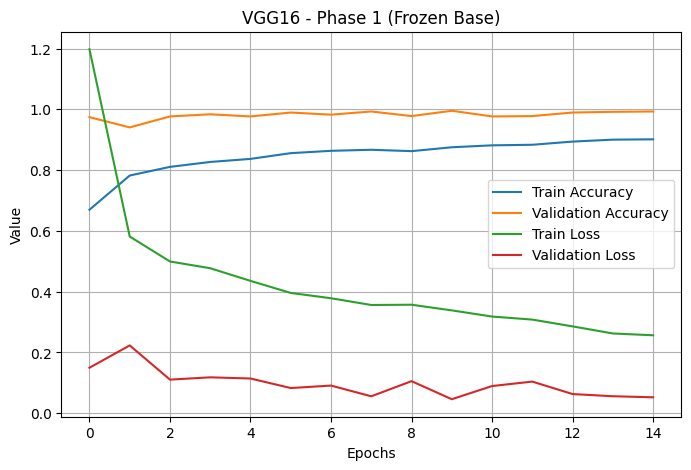

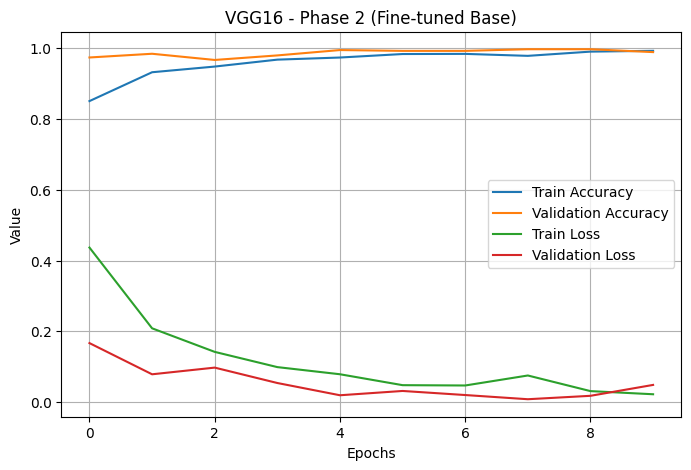

Final Training Accuracy (Phase 2): 0.9920
Best Validation Accuracy (Phase 2): 0.9965
Final Training Loss (Phase 2): 0.0225
Best Validation Loss (Phase 2): 0.0085


In [ ]:
# --- Visualize Training History ---
import matplotlib.pyplot as plt
import pandas as pd

def plot_history(hist, title="Model Training History"):
    hist_df = pd.DataFrame(hist.history)
    plt.figure(figsize=(8, 5))
    plt.plot(hist_df["accuracy"], label="Train Accuracy")
    plt.plot(hist_df["val_accuracy"], label="Validation Accuracy")
    plt.plot(hist_df["loss"], label="Train Loss")
    plt.plot(hist_df["val_loss"], label="Validation Loss")
    plt.title(title)
    plt.xlabel("Epochs")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True)
    plt.show()

# Plot both training phases if available
plot_history(hist1, "VGG16 - Phase 1 (Frozen Base)")
plot_history(hist2, "VGG16 - Phase 2 (Fine-tuned Base)")

# --- Print summary metrics ---
print(f"Final Training Accuracy (Phase 2): {hist2.history['accuracy'][-1]:.4f}")
print(f"Best Validation Accuracy (Phase 2): {max(hist2.history['val_accuracy']):.4f}")
print(f"Final Training Loss (Phase 2): {hist2.history['loss'][-1]:.4f}")
print(f"Best Validation Loss (Phase 2): {min(hist2.history['val_loss']):.4f}")


Evaluate on test set + confusion matrix & report

41/41 ━━━━━━━━━━━━━━━━━━━━ 437s 10s/step - accuracy: 0.9517 - loss: 0.1685 - precision: 0.9537 - recall: 0.9517
Test metrics: {'accuracy': 0.9649389982223511, 'loss': 0.13223211467266083, 'precision': 0.9656750559806824, 'recall': 0.9649389982223511}
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step
              precision    recall  f1-score   support

      glioma       0.99      0.94      0.96       300
  meningioma       0.92      0.95      0.94       306
     notumor       0.99      0.97      0.98       406
   pituitary       0.96      1.00      0.98       300

    accuracy                           0.96      1312
   macro avg       0.96      0.96      0.96      1312
weighted avg       0.97      0.96      0.97      1312



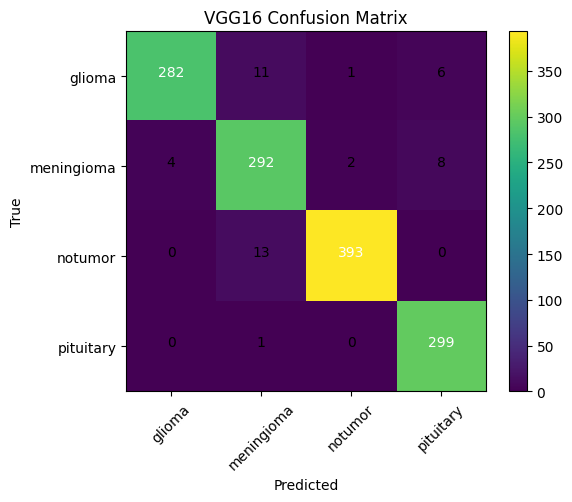

Macro ROC-AUC: 0.9980207683718156


In [ ]:
import numpy as np, itertools, matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize

# Evaluate
test_metrics = model.evaluate(test_pp, return_dict=True)
print("Test metrics:", test_metrics)

# Predictions
y_prob = model.predict(test_pp)
y_true = np.argmax(np.vstack([y.numpy() for _, y in test_ds.unbatch().batch(10000)]), axis=1)
y_pred = np.argmax(y_prob, axis=1)

print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation='nearest'); plt.title("VGG16 Confusion Matrix"); plt.colorbar()
ticks = np.arange(len(class_names))
plt.xticks(ticks, class_names, rotation=45); plt.yticks(ticks, class_names)
th = cm.max()/2.
for i,j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i,j], ha="center", color="white" if cm[i,j] > th else "black")
plt.ylabel('True'); plt.xlabel('Predicted'); plt.tight_layout(); plt.show()

# Macro ROC-AUC (one-vs-rest) – optional but nice
y_true_bin = label_binarize(y_true, classes=list(range(len(class_names))))
macro_auc = roc_auc_score(y_true_bin, y_prob, average="macro", multi_class="ovr")
print("Macro ROC-AUC:", macro_auc)


test one image from test dataset

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Class order: ['glioma', 'meningioma', 'notumor', 'pituitary']
Predicted: glioma | True: glioma
Probabilities: {'glioma': 1.0, 'meningioma': 0.0, 'notumor': 0.0, 'pituitary': 0.0}


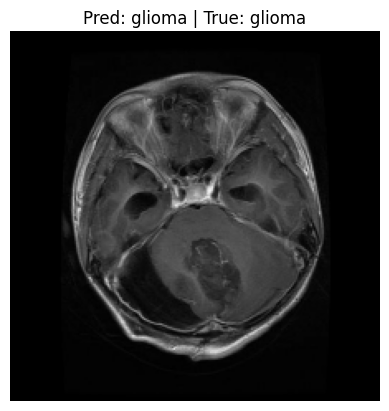

In [ ]:
import tensorflow as tf, numpy as np, matplotlib.pyplot as plt
from tensorflow.keras.applications.vgg16 import preprocess_input

IMG_SIZE = 224  # keep same as training

# (Optional) load best weights if you saved them
import os
if os.path.exists("vgg16_best.h5"):
    model.load_weights("vgg16_best.h5")

# take exactly one image from the test set
for img, label in test_ds.unbatch().take(1):
    # keep a copy for plotting
    vis = tf.cast(img, tf.uint8).numpy()

    # resize + preprocess for VGG16
    x = tf.image.resize(img[None, ...], (IMG_SIZE, IMG_SIZE))
    x = tf.cast(x, tf.float32)
    x = preprocess_input(x)

    # predict
    probs = model.predict(x)
    pred_idx = int(np.argmax(probs[0]))
    true_idx = int(tf.argmax(label).numpy())

    # pretty print
    print("Class order:", class_names)
    print("Predicted:", class_names[pred_idx], "| True:", class_names[true_idx])
    print("Probabilities:", {c: float(f"{p:.3f}") for c, p in zip(class_names, probs[0])})

    # visualize
    plt.imshow(vis); plt.axis("off")
    plt.title(f"Pred: {class_names[pred_idx]} | True: {class_names[true_idx]}")
    plt.show()
    break


test one mini-batch

In [ ]:
import numpy as np

# If you built test_pp (already preprocessed), use test_pp; else use test_ds with manual preprocess
use_preprocessed = True  # set to False if you didn't build test_pp

if use_preprocessed:
    for xb, yb in test_pp.take(1):
        probs = model.predict(xb)
        preds = probs.argmax(axis=1)
        trues = yb.numpy().argmax(axis=1)
        acc = (preds == trues).mean()
        print("Mini-batch accuracy:", acc)
        print("Pred →", [class_names[i] for i in preds[:8]])
        print("True →", [class_names[i] for i in trues[:8]])
        break
else:
    from tensorflow.keras.applications.vgg16 import preprocess_input
    # manually preprocess this batch
    for xb, yb in test_ds.take(1):
        xb = tf.image.resize(xb, (IMG_SIZE, IMG_SIZE))
        xb = preprocess_input(tf.cast(xb, tf.float32))
        probs = model.predict(xb)
        preds = probs.argmax(axis=1)
        trues = yb.numpy().argmax(axis=1)
        acc = (preds == trues).mean()
        print("Mini-batch accuracy:", acc)
        print("Pred →", [class_names[i] for i in preds[:8]])
        print("True →", [class_names[i] for i in trues[:8]])
        break


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 947ms/step
Mini-batch accuracy: 0.96875
Pred → ['glioma', 'glioma', 'glioma', 'glioma', 'pituitary', 'glioma', 'glioma', 'glioma']
True → ['glioma', 'glioma', 'glioma', 'glioma', 'glioma', 'glioma', 'glioma', 'glioma']


test from a file path

In [ ]:
import numpy as np, tensorflow as tf
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras.applications.vgg16 import preprocess_input

def predict_file(path):
    img = load_img(path, target_size=(IMG_SIZE, IMG_SIZE))
    x = img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x.astype("float32"))
    probs = model.predict(x)
    pred_idx = int(np.argmax(probs[0]))
    return class_names[pred_idx], {c: float(f"{p:.3f}") for c, p in zip(class_names, probs[0])}

pred, prob_dict = predict_file("/content/drive/MyDrive/DL-Assignment/brain_tumor_dataset/Testing/glioma/Te-gl_0010.jpg")  # change path
print("Predicted:", pred)
print("Probabilities:", prob_dict)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Predicted: glioma
Probabilities: {'glioma': 1.0, 'meningioma': 0.0, 'notumor': 0.0, 'pituitary': 0.0}


save the model

In [ ]:
import json, os

SAVE_DIR = "/content/drive/MyDrive/DL-Assignment/vgg16"
os.makedirs(SAVE_DIR, exist_ok=True)

# 1) Save the full model (includes architecture + weights)
model.save(f"{SAVE_DIR}/vgg16_phase2.keras")   # after fine-tuning

# 2) Save class names so label order stays consistent
with open(f"{SAVE_DIR}/class_names.json", "w") as f:
    json.dump(class_names, f)

# (Optional) Keep a checkpoint too (you already used ModelCheckpoint)
# It's handy if you ever want to reload just weights:
# model.save_weights(f"{SAVE_DIR}/vgg16_best.weights.h5")


NameError: name 'model' is not defined

In [ ]:
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np


def predict_file(path):
    img = load_img(path, target_size=(IMG_SIZE, IMG_SIZE))
    x = img_to_array(img)[None, ...].astype("float32")
    x = preprocess_input(x)
    probs = model.predict(x)[0]
    pred = class_names[int(np.argmax(probs))]
    return pred, {c: float(f"{p:.3f}") for c, p in zip(class_names, probs)}

pred, prob = predict_file(f"{TEST_DIR}/meningioma/Te-me_0019.jpg")  # change file
print("Predicted:", pred)
print("Probs:", prob)


NameError: name 'preprocess_input' is not defined

Use saved Model

In [ ]:
# 0) Mount Drive
from google.colab import drive
drive.mount('/content/drive')

# 1) Load saved model + class names
import json, tensorflow as tf
from tensorflow.keras.models import load_model

SAVE_DIR  = "/content/drive/MyDrive/DL-Assignment/vgg16"
model = load_model(f"{SAVE_DIR}/vgg16_phase2.keras")

with open(f"{SAVE_DIR}/class_names.json") as f:
    class_names = json.load(f)

# 2) Build ONLY the test dataset
IMG_SIZE = 224
BATCH    = 32
TEST_DIR = "/content/drive/MyDrive/DL-Assignment/brain_tumor_dataset/Testing"

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH,
    label_mode="categorical",
    shuffle=False
)

# 3) Preprocess for VGG16 and evaluate
from tensorflow.keras.applications.vgg16 import preprocess_input
test_pp = (test_ds
           .map(lambda x,y: (preprocess_input(tf.cast(x, tf.float32)), y),
                num_parallel_calls=tf.data.AUTOTUNE)
           .prefetch(tf.data.AUTOTUNE))

metrics = model.evaluate(test_pp, return_dict=True)
print("Test metrics:", metrics)


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 32 variables whereas the saved optimizer has 66 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Found 1312 files belonging to 4 classes.
41/41 ━━━━━━━━━━━━━━━━━━━━ 320s 7s/step - accuracy: 0.9531 - loss: 0.1402 - precision: 0.9560 - recall: 0.9513
Test metrics: {'accuracy': 0.9641768336296082, 'loss': 0.10663289576768875, 'precision': 0.9655963182449341, 'recall': 0.9626524448394775}


**Per-class report + confusion matrix**

41/41 ━━━━━━━━━━━━━━━━━━━━ 8s 154ms/step
              precision    recall  f1-score   support

      glioma       0.99      0.96      0.97       300
  meningioma       0.97      0.90      0.93       306
     notumor       0.99      0.99      0.99       406
   pituitary       0.91      1.00      0.95       300

    accuracy                           0.96      1312
   macro avg       0.96      0.96      0.96      1312
weighted avg       0.97      0.96      0.96      1312



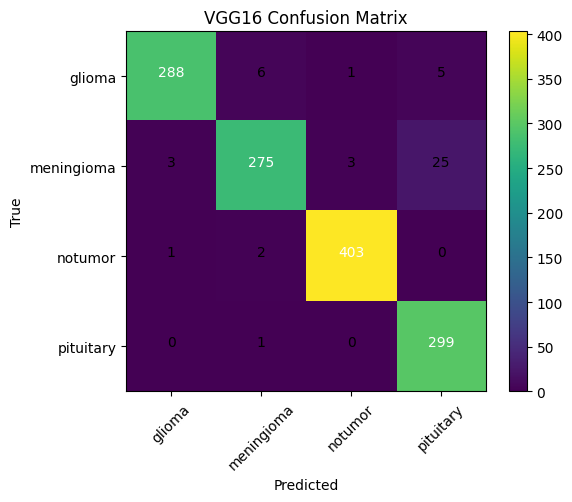

In [ ]:
import numpy as np, itertools, matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.applications.vgg16 import preprocess_input

# get predictions on test set
y_true = np.argmax(np.vstack([y.numpy() for _,y in test_ds.unbatch().batch(10000)]), axis=1)
y_prob = model.predict(test_pp)  # if you built test_pp with preprocess_input; otherwise preprocess manually
y_pred = np.argmax(y_prob, axis=1)

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation='nearest'); plt.title("VGG16 Confusion Matrix"); plt.colorbar()
ticks = np.arange(len(class_names))
plt.xticks(ticks, class_names, rotation=45); plt.yticks(ticks, class_names)
th = cm.max()/2.
for i,j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i,j], ha="center", color="white" if cm[i,j] > th else "black")
plt.ylabel('True'); plt.xlabel('Predicted'); plt.tight_layout(); plt.show()
